# Bayesian Workflow without Fragile PyMC3 Dependencies

This notebook keeps the PyMC-style workflow: define prior, condition on data, sample posterior, inspect credible intervals.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from bayesian_utils import ensure_output_dir, simulate_strategy_returns

sns.set_theme(style='whitegrid', context='notebook')
pd.set_option('display.float_format', lambda x: f'{x:,.4f}')
OUTPUT = ensure_output_dir()
from bayesian_utils import credible_interval, normal_mean_posterior, sample_posterior_normal


In [2]:
returns = simulate_strategy_returns(periods=756, seed=202)
posterior_summary = {
    column: normal_mean_posterior(returns[column], prior_mean=0.0, prior_std=0.01)
    for column in ['quality', 'momentum', 'defensive']
}
pd.DataFrame(posterior_summary).T

,posterior_mean,posterior_std,sample_mean,sample_std,n
quality,0.0001,0.0004,0.0001,0.0097,756.0000
momentum,-0.0001,0.0005,-0.0001,0.0140,756.0000
defensive,-0.0001,0.0002,-0.0001,0.0064,756.0000


In [3]:
posterior_draws = pd.DataFrame({
    column: sample_posterior_normal(summary, seed=300 + i)
    for i, (column, summary) in enumerate(posterior_summary.items())
})
credible = pd.DataFrame({
    column: credible_interval(posterior_draws[column].to_numpy()).__dict__
    for column in posterior_draws
}).T
credible.to_csv(OUTPUT / 'normal_mean_posterior.csv')
credible

,mean,lower,upper
quality,0.0001,-0.0006,0.0008
momentum,-0.0001,-0.0011,0.0009
defensive,-0.0001,-0.0006,0.0003


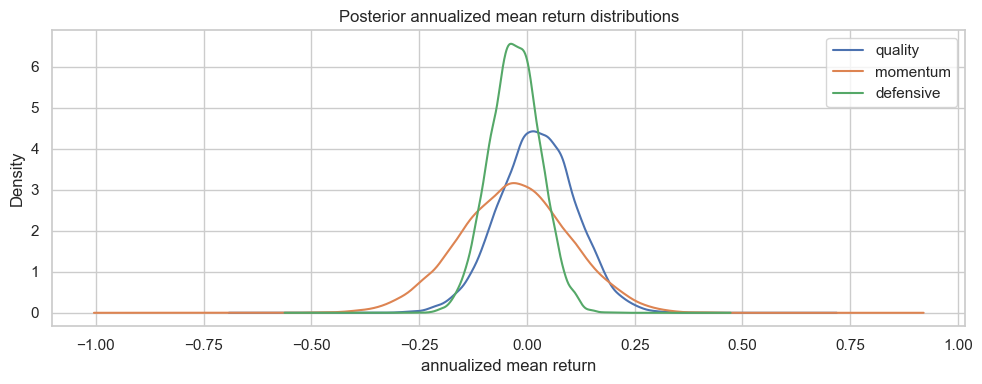

In [4]:
fig, ax = plt.subplots(figsize=(10, 4))
posterior_draws.mul(252).plot(kind='density', ax=ax)
ax.set(title='Posterior annualized mean return distributions', xlabel='annualized mean return')
plt.tight_layout()